# Logistics Prioritization Notebook

This notebook turns the marketplace analysis into an operational prioritization model. The goal is to rank where limited logistics improvement capacity should be deployed first.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

BASE = Path('dataset/dataset')

In [3]:
orders = pd.read_csv(BASE / 'marketplace_transactions.csv', parse_dates=['purchase_timestamp','approved_at','shipped_date','delivered_date','estimated_delivery_date'])
feedback = pd.read_csv(BASE / 'feedback.csv', parse_dates=['feedback_date']).sort_values(['transaction_id','feedback_date']).drop_duplicates('transaction_id', keep='last')
details = pd.read_csv(BASE / 'transaction_details.csv')
items = pd.read_csv(BASE / 'items.csv')
translations = pd.read_csv(BASE / 'item_category_translation.csv')
buyers = pd.read_csv(BASE / 'buyers.csv')
artisans = pd.read_csv(BASE / 'artisans.csv')

In [4]:
def pick_mode(series):
    mode = series.mode(dropna=True)
    if len(mode):
        return mode.iloc[0]
    series = series.dropna()
    return series.iloc[0] if len(series) else np.nan

line = details.merge(items[['item_id','item_category_name','item_weight_g']], on='item_id', how='left')
line = line.merge(translations, on='item_category_name', how='left')
line['category'] = line['item_category_name_english'].fillna(line['item_category_name'])
line = line.merge(artisans[['artisan_id','artisan_state','artisan_city']], on='artisan_id', how='left')

order_lines = line.groupby('transaction_id').agg(
    items=('transaction_item_id', 'size'),
    artisans=('artisan_id', 'nunique'),
    order_price=('price', 'sum'),
    order_ship=('shipping_cost', 'sum'),
    total_weight=('item_weight_g', 'sum'),
    category=('category', pick_mode),
    artisan_id=('artisan_id', pick_mode),
    artisan_state=('artisan_state', pick_mode),
    artisan_city=('artisan_city', pick_mode),
).reset_index()

order = (orders
    .merge(order_lines, on='transaction_id', how='left')
    .merge(buyers[['buyer_id','buyer_unique_id','buyer_state','buyer_city']], on='buyer_id', how='left')
    .merge(feedback[['transaction_id','rating_score']], on='transaction_id', how='left'))

order['gross_value'] = order['order_price'] + order['order_ship']
order['delivery_days'] = (order['delivered_date'] - order['purchase_timestamp']).dt.total_seconds() / 86400
order['late'] = order['delivered_date'] > order['estimated_delivery_date']
order['cross_state'] = order['buyer_state'] != order['artisan_state']
order['ship_share'] = order['order_ship'] / order['gross_value']
order['purchase_month'] = order['purchase_timestamp'].dt.to_period('M').astype(str)
order[['transaction_id','category','buyer_state','artisan_state','late']].head()

,transaction_id,category,buyer_state,artisan_state,late
0,e481f51cbdc54678b7cc49136f2d6af7,housewares,SP,SP,False
1,53cdb2fc8bc7dce0b6741e2150273451,perfumery,BA,SP,False
2,47770eb9100c2d0c44946d9cf07ec65d,auto,GO,SP,False
3,949d5b44dbf5de918fe9c16f97b45f8a,pet_shop,RN,MG,False
4,ad21c59c0840e6cb83a9ceb5573f8159,stationery,SP,SP,False


## Define prioritization units

A good operational unit is a `seller-state-category lane`: one artisan, shipping into one buyer state, for one product category. This is granular enough to act on, but still interpretable.

In [5]:
lane = order.groupby(['artisan_id','artisan_state','buyer_state','category']).agg(
    orders=('transaction_id','size'),
    gmv=('gross_value','sum'),
    avg_order=('gross_value','mean'),
    avg_delivery=('delivery_days','mean'),
    late_rate=('late','mean'),
    avg_rating=('rating_score','mean'),
    ship_share=('ship_share','mean'),
    avg_weight=('total_weight','mean'),
    repeat_buyers=('buyer_unique_id', lambda s: s.nunique()),
).reset_index()

lane = lane.query('orders >= 10').copy()
lane['cross_state'] = lane['buyer_state'] != lane['artisan_state']
lane.shape

(1706, 14)

## Create a logistics risk score

The score below is heuristic rather than causal. It is designed to prioritize lanes that are simultaneously large, operationally painful, and customer-damaging.

Components used:
- volume
- GMV
- late rate
- delivery time
- shipping burden
- cross-state status
- low ratings

In [6]:
def minmax(s):
    s = s.astype(float)
    if s.max() == s.min():
        return pd.Series(0.0, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

lane['score_volume'] = minmax(np.log1p(lane['orders']))
lane['score_gmv'] = minmax(np.log1p(lane['gmv']))
lane['score_late'] = minmax(lane['late_rate'])
lane['score_delivery'] = minmax(lane['avg_delivery'].fillna(lane['avg_delivery'].median()))
lane['score_ship_share'] = minmax(lane['ship_share'].fillna(lane['ship_share'].median()))
lane['score_rating_penalty'] = minmax(5 - lane['avg_rating'].fillna(lane['avg_rating'].median()))
lane['score_cross_state'] = lane['cross_state'].astype(int)

lane['priority_score'] = (
    0.20 * lane['score_volume'] +
    0.20 * lane['score_gmv'] +
    0.25 * lane['score_late'] +
    0.15 * lane['score_delivery'] +
    0.10 * lane['score_ship_share'] +
    0.05 * lane['score_rating_penalty'] +
    0.05 * lane['score_cross_state']
)

lane.sort_values('priority_score', ascending=False).head(15)

,artisan_id,artisan_state,buyer_state,category,orders,gmv,avg_order,avg_delivery,late_rate,avg_rating,ship_share,avg_weight,repeat_buyers,cross_state,score_volume,score_gmv,score_late,score_delivery,score_ship_share,score_rating_penalty,score_cross_state,priority_score
3277,1f50f920176fa81dab994f9023523100,SP,RJ,garden_tools,216,"20,712.450",95.891,20.920,0.250,3.665,0.246,"2,140.509",215,True,0.731,0.765,0.357,0.534,0.387,0.405,1,0.577
12295,7c67e1448b00f6e969d365cea6b010ab,SP,RJ,office_furniture,159,"42,816.250",269.285,26.213,0.145,3.214,0.218,"17,122.692",156,True,0.656,0.884,0.207,0.687,0.339,0.541,1,0.574
4458,2c9e548be18521d1c43cde1c582c6de8,SP,RJ,stationery,14,825.600,58.971,34.432,0.571,2.643,0.396,700.000,14,True,0.076,0.236,0.816,0.926,0.641,0.714,1,0.555
13597,88460e8ebdecbfecb5f9601833981930,PR,MG,computers_accessories,30,"4,945.010",164.834,25.329,0.500,2.966,0.177,315.500,29,True,0.254,0.530,0.714,0.662,0.271,0.617,1,0.542
7125,4a3ca9315b744ce9f8e9374361493884,SP,RJ,bed_bath_table,222,"31,797.170",143.230,17.134,0.185,3.682,0.175,"2,525.770",222,True,0.737,0.835,0.264,0.424,0.266,0.399,1,0.541
13969,8b321bb669392f5163d04c59e235e066,SP,RJ,electronics,129,"4,341.100",33.652,18.669,0.248,3.698,0.495,187.519,129,True,0.605,0.508,0.354,0.468,0.811,0.395,1,0.532
6945,4869f7a5dfa277a7dca6462dcf3b52b2,SP,RJ,watches_gifts,171,"36,342.310",212.528,18.683,0.205,3.868,0.094,992.456,168,True,0.674,0.857,0.292,0.469,0.128,0.343,1,0.530
698,06a2c3af7b3aee5d69171b0e14f0ee87,MA,SP,health_beauty,125,"15,914.140",127.313,16.093,0.248,3.887,0.273,532.400,124,True,0.598,0.722,0.354,0.394,0.434,0.337,1,0.522
11086,712e6ed8aa4aa1fa65dab41fed5737e4,SC,MG,auto,12,"7,296.680",608.057,36.981,0.417,3.417,0.128,"19,441.667",12,True,0.041,0.593,0.595,1.000,0.187,0.480,1,0.518
21816,e5a3438891c0bfdb9394643f95273d8e,SP,RJ,fashion_bags_accessories,12,563.970,46.998,30.154,0.583,2.667,0.372,279.167,10,True,0.041,0.173,0.833,0.802,0.602,0.707,1,0.517


## Highest-priority logistics lanes

In [7]:
top_lanes = lane.sort_values('priority_score', ascending=False).head(20)
top_lanes[['artisan_id','artisan_state','buyer_state','category','orders','gmv','avg_delivery','late_rate','avg_rating','ship_share','priority_score']]

,artisan_id,artisan_state,buyer_state,category,orders,gmv,avg_delivery,late_rate,avg_rating,ship_share,priority_score
3277,1f50f920176fa81dab994f9023523100,SP,RJ,garden_tools,216,"20,712.450",20.920,0.250,3.665,0.246,0.577
12295,7c67e1448b00f6e969d365cea6b010ab,SP,RJ,office_furniture,159,"42,816.250",26.213,0.145,3.214,0.218,0.574
4458,2c9e548be18521d1c43cde1c582c6de8,SP,RJ,stationery,14,825.600,34.432,0.571,2.643,0.396,0.555
13597,88460e8ebdecbfecb5f9601833981930,PR,MG,computers_accessories,30,"4,945.010",25.329,0.500,2.966,0.177,0.542
7125,4a3ca9315b744ce9f8e9374361493884,SP,RJ,bed_bath_table,222,"31,797.170",17.134,0.185,3.682,0.175,0.541
13969,8b321bb669392f5163d04c59e235e066,SP,RJ,electronics,129,"4,341.100",18.669,0.248,3.698,0.495,0.532
6945,4869f7a5dfa277a7dca6462dcf3b52b2,SP,RJ,watches_gifts,171,"36,342.310",18.683,0.205,3.868,0.094,0.530
698,06a2c3af7b3aee5d69171b0e14f0ee87,MA,SP,health_beauty,125,"15,914.140",16.093,0.248,3.887,0.273,0.522
11086,712e6ed8aa4aa1fa65dab41fed5737e4,SC,MG,auto,12,"7,296.680",36.981,0.417,3.417,0.128,0.518
21816,e5a3438891c0bfdb9394643f95273d8e,SP,RJ,fashion_bags_accessories,12,563.970,30.154,0.583,2.667,0.372,0.517


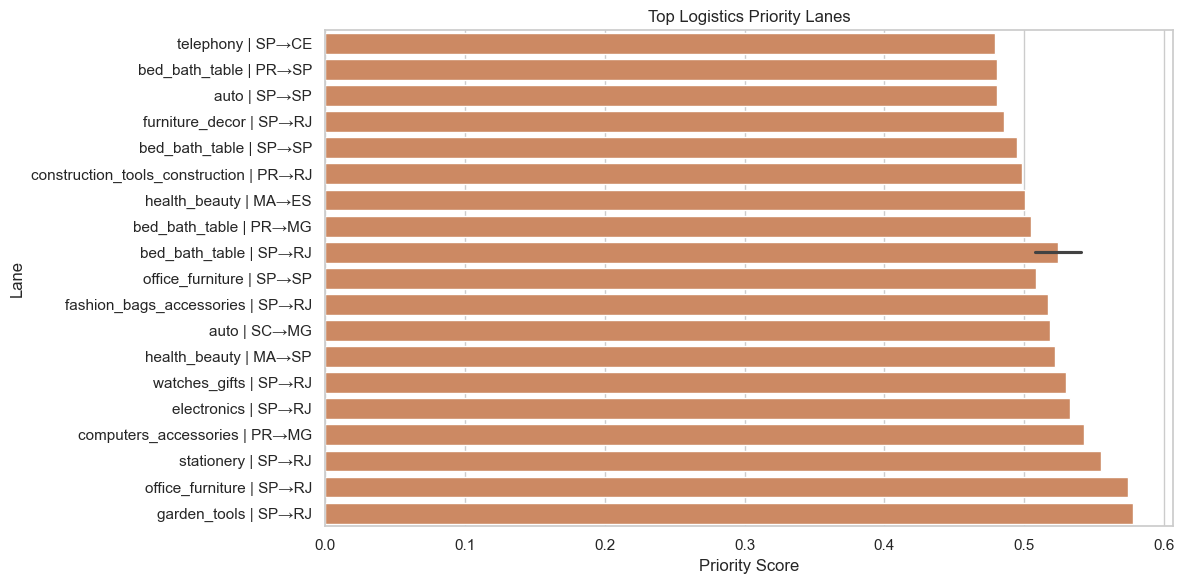

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = top_lanes.sort_values('priority_score', ascending=True).copy()
plot_df['lane_label'] = plot_df['category'].astype(str) + ' | ' + plot_df['artisan_state'].astype(str) + '→' + plot_df['buyer_state'].astype(str)
sns.barplot(data=plot_df, y='lane_label', x='priority_score', ax=ax, color='#dd8452')
ax.set_title('Top Logistics Priority Lanes')
ax.set_xlabel('Priority Score')
ax.set_ylabel('Lane')
plt.tight_layout()

## Prioritize by buyer state and category

This view is less granular and more useful for strategic interventions such as regional carrier review, service-level resets, or local seller recruitment.

In [9]:
state_category = order.groupby(['buyer_state','category']).agg(
    orders=('transaction_id','size'),
    gmv=('gross_value','sum'),
    avg_delivery=('delivery_days','mean'),
    late_rate=('late','mean'),
    avg_rating=('rating_score','mean'),
    ship_share=('order_ship', lambda s: s.sum() / order.loc[s.index, 'gross_value'].sum())
).reset_index()
state_category = state_category.query('orders >= 100').copy()
state_category['priority_score'] = (
    0.25 * minmax(np.log1p(state_category['orders'])) +
    0.20 * minmax(np.log1p(state_category['gmv'])) +
    0.30 * minmax(state_category['late_rate']) +
    0.15 * minmax(state_category['avg_delivery'].fillna(state_category['avg_delivery'].median())) +
    0.10 * minmax(5 - state_category['avg_rating'].fillna(state_category['avg_rating'].median()))
)
state_category.sort_values('priority_score', ascending=False).head(20)

,buyer_state,category,orders,gmv,avg_delivery,late_rate,avg_rating,ship_share,priority_score
919,RJ,bed_bath_table,1389,"182,371.770",16.816,0.161,3.743,0.179,0.720
982,RJ,watches_gifts,806,"197,020.100",15.016,0.144,3.818,0.070,0.637
977,RJ,sports_leisure,910,"144,856.150",15.670,0.147,3.907,0.143,0.634
951,RJ,furniture_decor,843,"122,928.030",16.470,0.138,3.754,0.193,0.625
954,RJ,garden_tools,542,"89,027.140",16.732,0.159,3.780,0.179,0.615
927,RJ,computers_accessories,857,"142,781.160",16.087,0.134,3.879,0.150,0.613
938,RJ,electronics,398,"34,385.190",16.912,0.198,3.832,0.235,0.613
918,RJ,baby,343,"51,535.520",16.794,0.175,3.740,0.170,0.590
165,BA,health_beauty,329,"60,479.260",19.454,0.164,3.873,0.147,0.588
187,BA,telephony,226,"25,524.930",19.294,0.181,3.625,0.174,0.571


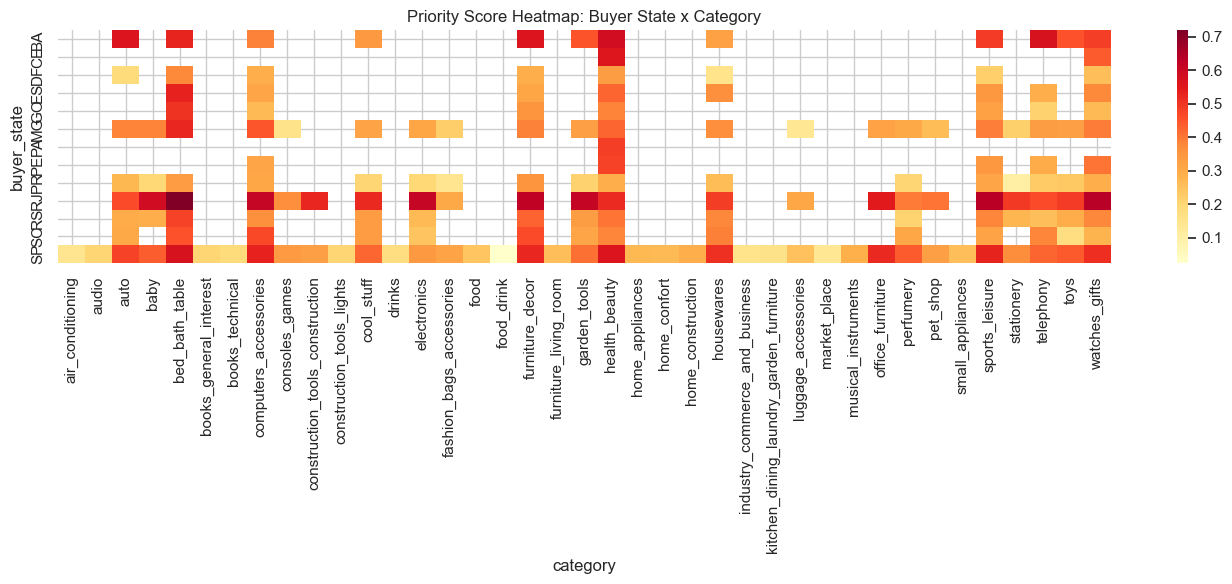

In [10]:
heat = state_category.pivot_table(index='buyer_state', columns='category', values='priority_score')
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heat, cmap='YlOrRd', ax=ax)
ax.set_title('Priority Score Heatmap: Buyer State x Category')
plt.tight_layout()

## Simulate limited intervention capacity

Assume the business can only intervene on a limited number of lanes. This section estimates how much pain sits inside the top-priority set.

In [11]:
lane_eval = lane.sort_values('priority_score', ascending=False).copy()
lane_eval['late_orders'] = lane_eval['orders'] * lane_eval['late_rate']
for k in [5, 10, 20, 50]:
    subset = lane_eval.head(k)
    print({
        'top_k_lanes': k,
        'orders_covered': int(subset['orders'].sum()),
        'gmv_covered': round(subset['gmv'].sum(), 2),
        'estimated_late_orders': round(subset['late_orders'].sum(), 1),
        'avg_priority_score': round(subset['priority_score'].mean(), 3),
    })

{'top_k_lanes': 5, 'orders_covered': 641, 'gmv_covered': np.float64(101096.48), 'estimated_late_orders': np.float64(141.0), 'avg_priority_score': np.float64(0.558)}
{'top_k_lanes': 10, 'orders_covered': 1090, 'gmv_covered': np.float64(165554.68), 'estimated_late_orders': np.float64(251.0), 'avg_priority_score': np.float64(0.541)}
{'top_k_lanes': 20, 'orders_covered': 2424, 'gmv_covered': np.float64(401010.14), 'estimated_late_orders': np.float64(410.0), 'avg_priority_score': np.float64(0.517)}
{'top_k_lanes': 50, 'orders_covered': 6090, 'gmv_covered': np.float64(948161.15), 'estimated_late_orders': np.float64(800.0), 'avg_priority_score': np.float64(0.484)}


## Recommendations from the prioritization model

Use the ranked outputs to drive action in this sequence:

1. Intervene first on the top seller-state-category lanes with high late rates and meaningful order volume.
2. Review major cross-state lanes into high-friction states such as `RJ`, `BA`, `ES`, `PE`, and `SC`.
3. Use local-seller ranking or regional inventory positioning for categories with heavy shipping burden.
4. Track whether interventions reduce late rates and raise ratings in the targeted lanes.

This notebook is a prioritization tool, not a final optimizer. It is meant to tell the team where to focus first.